# Analyse Simulatieresultaten

Laadt opgeslagen runs uit `results/` en analyseert de resultaten.

In [9]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from run_simulation import load_all_runs

## 1. Runs laden en selecteren

In [18]:
runs = load_all_runs()

display(runs[[
    "n_freight", "trigger_strategy", "objective_strategy",
    "event_driven_freq", "controller_freq", "periodic_freq",
    "threshold_confidence", "weight_passenger", "weight_freight",
    "dynamic_threshold", "seed",
    "ctrl_n_rescheduled", "ctrl_n_fcfs_fallback", "ctrl_n_skipped",
]])

,n_freight,trigger_strategy,objective_strategy,event_driven_freq,controller_freq,periodic_freq,threshold_confidence,weight_passenger,weight_freight,dynamic_threshold,seed,ctrl_n_rescheduled,ctrl_n_fcfs_fallback,ctrl_n_skipped
0,300,hybrid,static,900,300,1800,0.6,2,1,300,1,92,0,11096
1,300,hybrid,static,900,300,1800,0.6,2,1,300,2,95,0,11093


In [19]:
# Pas filter aan om de gewenste run te selecteren
run = runs[
    (runs["trigger_strategy"]   == "hybrid") &
    (runs["objective_strategy"] == "static") &
    (runs["n_freight"]          == 300) &
    (runs["seed"]          == 2)
].iloc[0]

df = pd.read_parquet(run["parquet_path"])

print(f"Run: {Path(run['parquet_path']).name}")
print(f"Resultaten: {len(df)} rijen, {df['train_id'].nunique()} treinen")
df.head()

Run: n300_hybrid_static_wp2_wf1_g300_edf900_cf300_pf1800_tc0.6_seed2_run1.parquet
Resultaten: 11188 rijen, 1328 treinen


,train_id,train_type,train_subtype,segment_id,planned_entry,planned_exit,actual_entry,actual_exit,entry_delay,exit_delay
0,10,P,ICE,36N:SCHAARBEEK-BRUSSEL-NOORD,76863.0,77043.0,76348.0,76526.0,0.0,0.0
1,10,P,ICE,BRUSSEL-NOORD -- platform 3,77043.0,77163.0,77182.0,77302.0,139.0,139.0
2,10,P,ICE,0-2:BRUSSEL-NOORD-BRUSSEL-CONGRES,77163.0,77283.0,77332.0,77442.0,169.0,159.0
3,10,P,ICE,BRUSSEL-CONGRES -- platform 1,77283.0,77313.0,77452.0,77482.0,169.0,169.0
4,10,P,ICE,0-2:BRUSSEL-CONGRES-BRUSSEL-CENTRAAL,77313.0,77343.0,77482.0,77569.0,169.0,226.0


## 2. Samenvatting vertragingen

In [20]:
df_delays = (
    df.sort_values("planned_entry")
      .groupby("train_id")
      .last()
      .reset_index()[["train_id", "train_type", "train_subtype", "exit_delay"]]
      .rename(columns={"exit_delay": "final_delay_s"})
)
df_delays["final_delay_min"] = df_delays["final_delay_s"] / 60

print("=== Eindvertraging per treintype ===")
print(df_delays.groupby("train_subtype")["final_delay_min"]
      .agg(["mean", "median", "max", "count"]).round(2))
print()
print("=== Overall ===")
print(f"  Treinen op tijd  (0s):     {(df_delays['final_delay_s'] == 0).sum():>4}")
print(f"  Treinen vertraagd (<5min): {((df_delays['final_delay_s'] > 0) & (df_delays['final_delay_s'] < 300)).sum():>4}")
print(f"  Treinen vertraagd (≥5min): {(df_delays['final_delay_s'] >= 300).sum():>4}")
print(f"  Gemiddelde vertraging:     {df_delays['final_delay_min'].mean():.2f} min")
print(f"  Maximale vertraging:       {df_delays['final_delay_min'].max():.2f} min")

=== Eindvertraging per treintype ===
                mean  median     max  count
train_subtype                              
EURST          14.35   14.07   37.05     36
IC             12.56   11.45   52.12    632
ICE            16.20   13.25   49.32     14
INT            14.64   11.17   32.97     21
L              10.82    9.48   42.02    325
freight         7.78    0.00  102.30    300

=== Overall ===
  Treinen op tijd  (0s):      174
  Treinen vertraagd (<5min):  337
  Treinen vertraagd (≥5min):  817
  Gemiddelde vertraging:     11.17 min
  Maximale vertraging:       102.30 min


## 3. Verdeling eindvertragingen

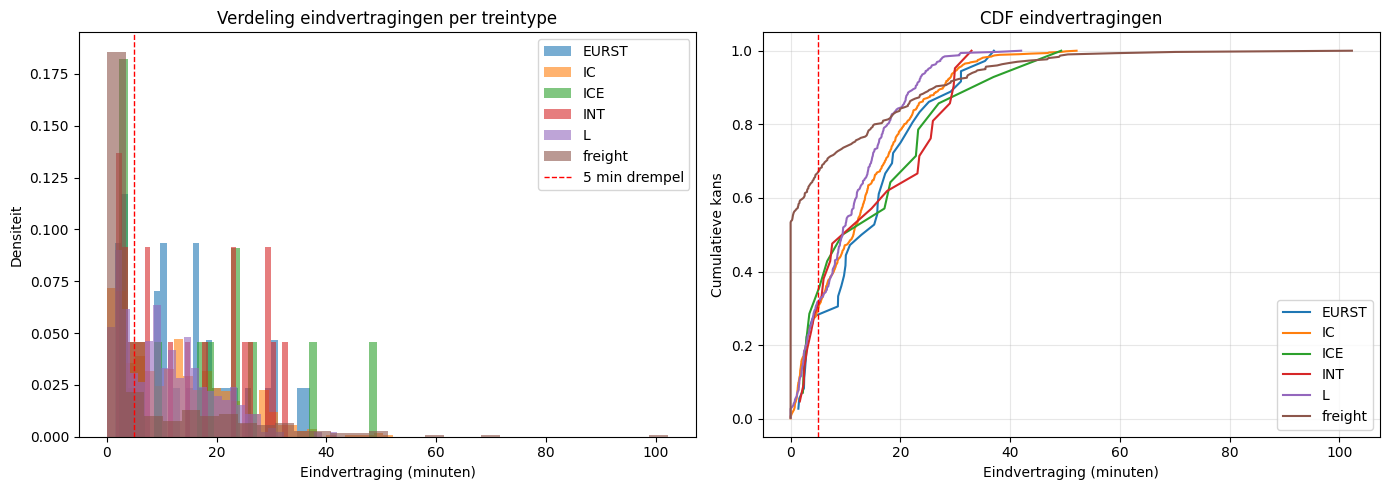

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for subtype, group in df_delays.groupby("train_subtype"):
    ax.hist(group["final_delay_min"], bins=30, alpha=0.6, label=subtype, density=True)
ax.axvline(5, color="red", linestyle="--", linewidth=1, label="5 min drempel")
ax.set_xlabel("Eindvertraging (minuten)")
ax.set_ylabel("Densiteit")
ax.set_title("Verdeling eindvertragingen per treintype")
ax.legend()

ax = axes[1]
for subtype, group in df_delays.groupby("train_subtype"):
    delays = group["final_delay_min"].sort_values()
    cdf    = np.arange(1, len(delays) + 1) / len(delays)
    ax.plot(delays, cdf, label=subtype)
ax.axvline(5, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Eindvertraging (minuten)")
ax.set_ylabel("Cumulatieve kans")
ax.set_title("CDF eindvertragingen")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Vertraging over de dag

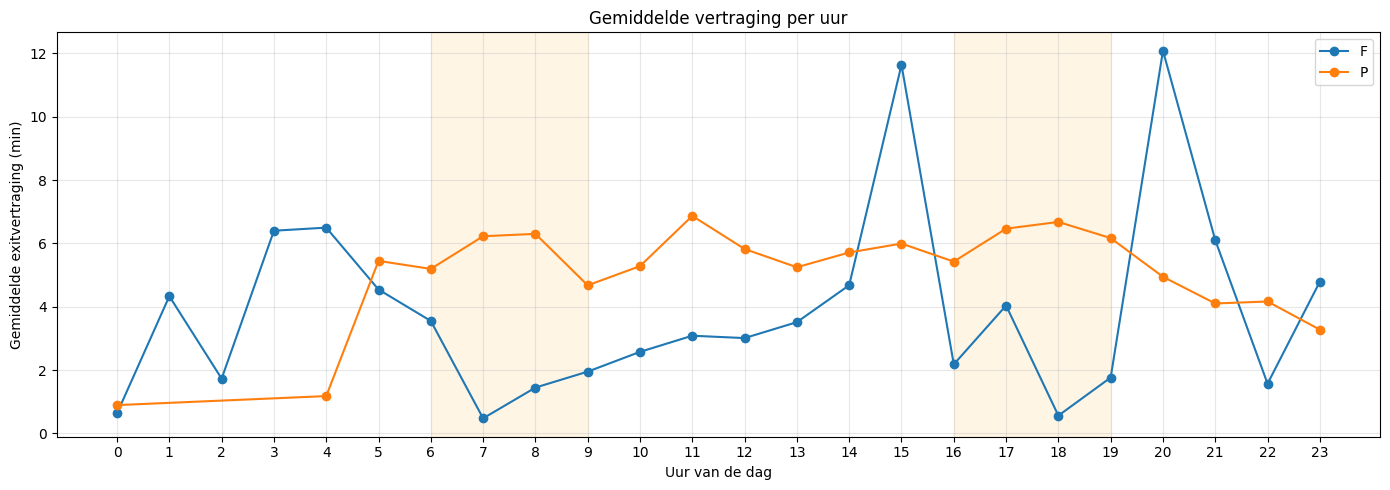

In [22]:
df["hour"]     = (df["planned_entry"] % 86400) / 3600
df["hour_bin"] = df["hour"].astype(int)

hourly = df.groupby(["hour_bin", "train_type"])["exit_delay"].mean().reset_index()
hourly["exit_delay_min"] = hourly["exit_delay"] / 60

fig, ax = plt.subplots(figsize=(14, 5))
for train_type, group in hourly.groupby("train_type"):
    ax.plot(group["hour_bin"], group["exit_delay_min"], marker="o", label=train_type)

ax.set_xlabel("Uur van de dag")
ax.set_ylabel("Gemiddelde exitvertraging (min)")
ax.set_title("Gemiddelde vertraging per uur")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, alpha=0.3)

for start, end, label in [(6, 9, "Morning Peak"), (16, 19, "Evening Peak")]:
    ax.axvspan(start, end, alpha=0.1, color="orange", label=label)

plt.tight_layout()
plt.show()

## 5. Controller samenvatting

In [23]:
print("=== Controller activiteit ===")
for key, val in run.items():
    if key.startswith("ctrl_"):
        print(f"  {key[5:]:<20}: {val}")

=== Controller activiteit ===
  n_rescheduled       : 95
  n_fcfs_fallback     : 0
  n_skipped           : 11093
  total_steps         : 11188


## 6. Sanity checks

In [24]:
n_neg_entry = (df["entry_delay"] < 0).sum()
n_neg_exit  = (df["exit_delay"]  < 0).sum()
n_overlap   = (df["actual_exit"] <= df["actual_entry"]).sum()

print(f"Negatieve entry_delay:   {n_neg_entry}  (verwacht: 0)")
print(f"Negatieve exit_delay:    {n_neg_exit}   (verwacht: 0)")
print(f"Rijen met exit <= entry: {n_overlap}    (verwacht: 0)")

Negatieve entry_delay:   0  (verwacht: 0)
Negatieve exit_delay:    0   (verwacht: 0)
Rijen met exit <= entry: 0    (verwacht: 0)
